In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn import metrics
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
import warnings

In [26]:
RANDOM_STATE = 40
TEST_SIZE = 0.2

In [27]:
df= pd.read_csv("C:\\Users\\Sepehr\\Desktop\\WineQT.csv") 

print(df.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [29]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1143.0,8.311111,1.747595,4.60000,7.10000,7.90000,9.100000,15.90000
volatile acidity,1143.0,0.531339,0.179633,0.12000,0.39250,0.52000,0.640000,1.58000
citric acid,1143.0,0.268364,0.196686,0.00000,0.09000,0.25000,0.420000,1.00000
residual sugar,1143.0,2.532152,1.355917,0.90000,1.90000,2.20000,2.600000,15.50000
chlorides,1143.0,0.086933,0.047267,0.01200,0.07000,0.07900,0.090000,0.61100
free sulfur dioxide,1143.0,15.615486,10.250486,1.00000,7.00000,13.00000,21.000000,68.00000
total sulfur dioxide,1143.0,45.914698,32.782130,6.00000,21.00000,37.00000,61.000000,289.00000
density,1143.0,0.996730,0.001925,0.99007,0.99557,0.99668,0.997845,1.00369
pH,1143.0,3.311015,0.156664,2.74000,3.20500,3.31000,3.400000,4.01000
sulphates,1143.0,0.657708,0.170399,0.33000,0.55000,0.62000,0.730000,2.00000


In [30]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
Id                      0
dtype: int64

In [31]:
for col in df.columns:
       if df[col].isnull().sum()> 0:
              df[col] = df[col].fillna(df[col].mean())

df.isnull().sum().sum()

np.int64(0)

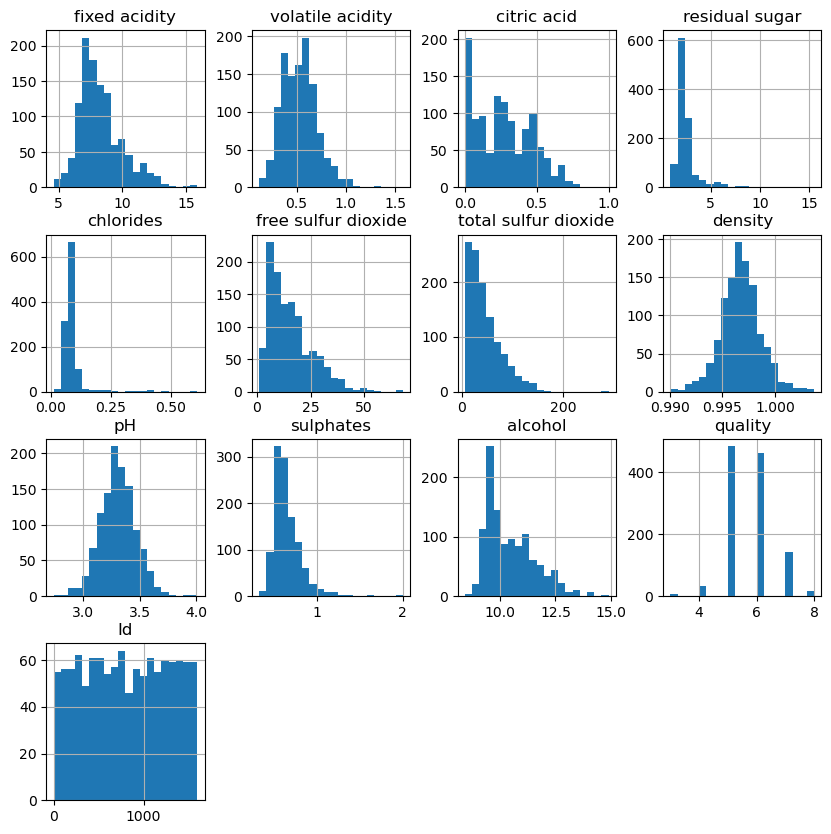

In [32]:
df.hist(bins=20, figsize=(10, 10))
plt.show()

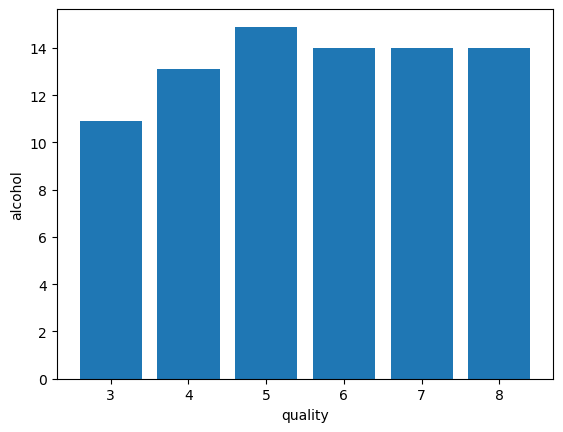

In [33]:
plt.bar(df['quality'], df['alcohol'])
plt.xlabel('quality')
plt.ylabel('alcohol')
plt.show()

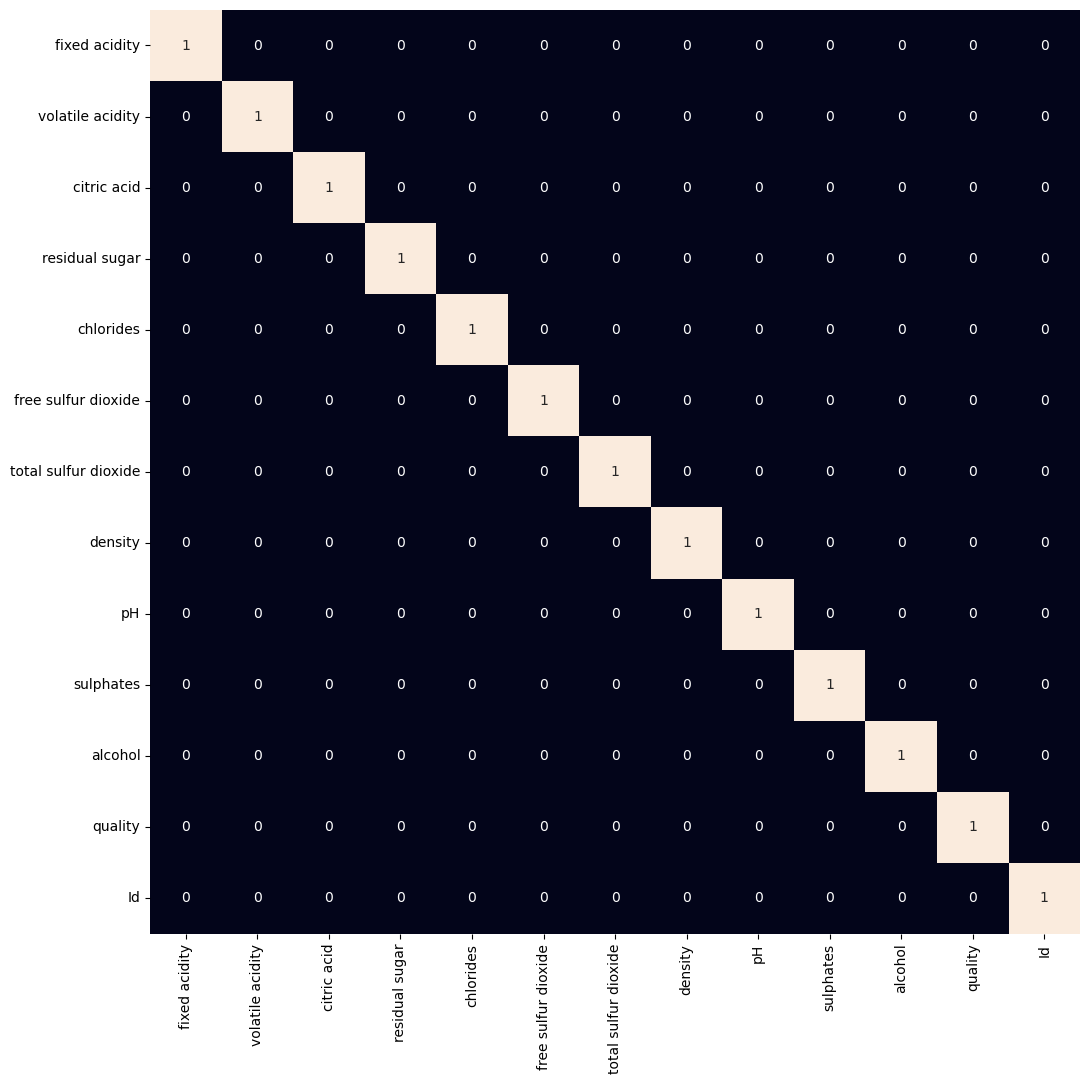

In [34]:
# Convert 'object' columns to numerical if they represent numbers
for col in df.columns:
    if df[col].dtype == 'object':
        try:
            df[col] = pd.to_numeric(df[col], errors='coerce')  # Convert to numeric, replace non-convertibles with NaN
        except:
            pass  # Skip columns that cannot be converted

plt.figure(figsize=(12, 12))
sb.heatmap(df.corr() > 0.7, annot=True, cbar=False)
plt.show()

# This code is modified by Susobhan Akhuli

In [35]:
df = df.drop('total sulfur dioxide', axis=1)

In [36]:
df['best quality'] = [1 if x > 5 else 0 for x in df.quality]

In [37]:
df.replace({'white': 1, 'red': 0}, inplace=True)

In [38]:
features = df.drop(['quality', 'best quality'], axis=1)
features = features.fillna(features.mean())
target = df['best quality']

xtrain, xtest, ytrain, ytest = train_test_split(
	features, target, test_size=0.2, random_state=40)

# Impute missing values after splitting
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # Or another strategy like 'median'
xtrain = imputer.fit_transform(xtrain)
xtest = imputer.transform(xtest)

xtrain.shape, xtest.shape

# This code is modified by Susobhan Akhuli

((914, 11), (229, 11))

In [39]:
norm = MinMaxScaler()
xtrain = norm.fit_transform(xtrain)
xtest = norm.transform(xtest)

In [45]:
import os
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import re

base_artifact_path = r"C:\\Users\\Sepehr\\Desktop"
os.makedirs(base_artifact_path, exist_ok=True)

mlflow.set_experiment("Wine Quality Prediction")

models = [LogisticRegression(), XGBClassifier(), SVC(kernel='rbf')]

for model in models:
    model_name = re.sub(r'[^a-zA-Z0-9_]', '', model.__class__.__name__)

    with mlflow.start_run(run_name=model_name):
        model.fit(xtrain, ytrain)

        ypred_train = model.predict(xtrain)
        ypred_test = model.predict(xtest)

        train_acc = metrics.roc_auc_score(ytrain, ypred_train)
        test_acc = metrics.roc_auc_score(ytest, ypred_test)

        # ثبت متریک‌ها در MLflow
        mlflow.log_metric("train_roc_auc", train_acc)
        mlflow.log_metric("test_roc_auc", test_acc)

        # ثبت مدل در MLflow و مسیر محلی دلخواه
        model_save_path = os.path.join(base_artifact_path, f"{model_name}_model")
        mlflow.sklearn.log_model(model, name="model")
        mlflow.sklearn.save_model(model, model_save_path)

        print(f"{model_name} : ")
        print(f"Training Accuracy : {train_acc}")
        print(f"Validation Accuracy : {test_acc}\n")

        # مسیر artifacts برای این مدل
        model_artifact_dir = os.path.join(base_artifact_path, model_name)
        os.makedirs(model_artifact_dir, exist_ok=True)

        # ذخیره‌ی Confusion Matrix
        cm = confusion_matrix(ytest, ypred_test)
        cm_path = os.path.join(model_artifact_dir, f"{model_name}_confusion_matrix.png")
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot()
        plt.savefig(cm_path)
        mlflow.log_artifact(cm_path)
        plt.close()

        # ذخیره‌ی Classification Report
        report = metrics.classification_report(ytest, ypred_test)
        report_path = os.path.join(model_artifact_dir, f"{model_name}_classification_report.txt")
        with open(report_path, 'w', encoding='utf-8') as f:
            f.write(report)
        mlflow.log_artifact(report_path)


2025/11/11 21:04:31 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogisticRegression : 
Training Accuracy : 0.7536725610489595
Validation Accuracy : 0.7255154639175256



2025/11/11 21:04:42 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBClassifier : 
Training Accuracy : 1.0
Validation Accuracy : 0.8022102467978757



2025/11/11 21:04:54 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


SVC : 
Training Accuracy : 0.7648213641284736
Validation Accuracy : 0.7358247422680412

